<a href="https://colab.research.google.com/github/RM-Amaral/MVP_STUDENT_DROPOUT/blob/main/mvp_student_dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Machine Learning & Analytics
## Previsão de Evasão e Sucesso Acadêmico de Estudantes do Ensino Superior

**Pós-Graduação em Ciência de Dados e Analytics PUC-Rio**
**Sprint:** Machine Learning & Analytics
**Autor:** Ricardo Matheus de Oliveira Amaral
**Dataset:** Predict Students' Dropout and Academic Success (UCI Machine Learning Repository)

---

Este notebook funciona como um relatório executável: cada etapa do fluxo de Machine Learning é acompanhada de explicações textuais que justificam as decisões tomadas, do problema à conclusão.


## 1. Apresentação do Problema

### 1.1 Contexto

Os dados foram coletados por uma instituição de ensino superior e reúnem informações de diversas bases disjuntas (dados acadêmicos no momento da matrícula, dados socioeconômicos, e desempenho acadêmico ao final do 1º e do 2º semestre) referentes a estudantes matriculados em diferentes cursos de graduação. O objetivo original da instituição é reduzir a evasão(*dropout*) e o insucesso acadêmico por meio da identificação precoce de estudantes em risco, permitindo ações de apoio e retenção antes que o abandono aconteça.

### 1.2 Objetivo do modelo

Construir um modelo de **classificação** que preveja a situação final do estudante (**Dropout**), **Enrolled** ou **Graduate**. A
partir do perfil socioeconômico, do percurso acadêmico anterior e do desempenho nas primeiras etapas do curso. O foco prático é que a instituição **priorize intervenções de apoio** para estudantes com maior risco de abandonar o curso.

### 1.3 Tipo de tarefa de Machine Learning

**Classificação multiclasse supervisionada** (3 classes: `Dropout`, `Enrolled`, `Graduate`). A
variável-alvo é categórica com mais de dois valores possíveis, o que distingue este problema do caso binário mais comum e exige métricas e estratégias de avaliação específicas (médias macro, matriz de confusão 3x3, AUC-ROC one-vs-rest).

### 1.4 Por que este problema pode ser tratado como Machine Learning

Há um volume razoável de exemplos históricos rotulados (4.424 estudantes com desfecho final conhecido) e a hipótese de que o desfecho acadêmico possa ser explicado, ao menos parcialmente, por um conjunto de variáveis (desempenho acadêmico inicial, situação socioeconômica, contexto macroconômico). Um modelo que estime a probabilidade de evasão permite priorizar o atendimento de estudantes por um serviço de apoio pedagógico com recursos limitados.

### 1.5 Premissas, hipóteses e restrições

- **Hipótese principal:** o desempenho acadêmico nas etapas iniciais do curso (unidades curriculares aprovadas e notas no 1º semestre) é o preditor mais forte da evasão, mais do que atributos puramente demográficos.
- **Hipótese secundária:** fatores socioeconômicos (ser devedor, estar com mensalidades em dia, ser bolsista, ser trabalhador e estudante) também influenciam a evasão, de forma independente do desempenho acadêmico.
- **Restrição crítica de vazamento temporal (*data leakage*):** o dataset contém desempenho acadêmico
  do **1º e do 2º semestre**. Para que o modelo seja **útil na prática** (permitir intervenção precoce),
  a versão principal deste MVP utiliza **apenas informações disponíveis até o final do 1º semestre**
  (matrícula + 1º semestre). Os atributos do 2º semestre são utilizados apenas em um **experimento de
  comparação isolado** (Seção 6.4), para evidenciar o ganho de desempenho de esperar mais um semestre.
- **Restrição de generalização:** os dados vêm de uma única instituição. Assim, conclusões podem não se generalizar diretamente para outras instituições.


## 0. Configuração do ambiente

Fixamos a *seed* de aleatoriedade para garantir reprodutibilidade e importamos as bibliotecas
utilizadas ao longo do notebook.


In [25]:
import time
_t0_notebook = time.time()

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)

print("Bibliotecas carregadas. Seed fixada em", RANDOM_STATE)


Bibliotecas carregadas. Seed fixada em 42


## 2. Apresentação dos Dados

**Fonte:** UCI Machine Learning Repository ([Predict Students' Dropout and Academic Success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success))
(Realinho, Vieira Martins, Machado e Baptista, 2021).

**Carregamento:** o CSV foi copiado para o repositório GitHub público deste MVP e é lido diretamente
por URL bruta (`raw.githubusercontent.com`), sem necessidade de upload manual, login ou chave de API.


**Critérios de escolha desta base:**
- Problema de classificação **multiclasse** (3 classes), diferente do caso binário mais trivial,
  permitindo demonstrar métricas e estratégias de avaliação mais ricas.
- Volume de dados adequado a um MVP (4.424 registros, 36 atributos), sem valores ausentes explícitos,
  o que desloca o desafio de preparação de dados para decisões mais sutis (codificação de categóricas,
  vazamento temporal) em vez de imputação trivial.
- Tema com valor social e institucional claro (retenção estudantil).


In [26]:
GITHUB_RAW_URL = "https://raw.githubusercontent.com/RM-Amaral/MVP_STUDENT_DROPOUT/main/data/predict_students_dropout.csv"

df_raw = pd.read_csv(GITHUB_RAW_URL, sep=";", encoding="utf-8-sig")
df_raw.columns = [c.strip().replace("\t", "") for c in df_raw.columns]

print("Dimensões do dataset:", df_raw.shape)
df_raw.head()

Dimensões do dataset: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [27]:
print(f"Registros: {df_raw.shape[0]:,}")
print(f"Atributos (sem contar o alvo): {df_raw.shape[1] - 1}")
print()
df_raw.info()


Registros: 4,424
Atributos (sem contar o alvo): 36

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   in

### 2.1 Descrição das principais variáveis

| Grupo | Atributos (exemplos) | Descrição |
|---|---|---|
| Demográfico | `Marital status`, `Gender`, `Age at enrollment`, `Nacionality`, `International` | Perfil do estudante |
| Socioeconômico | `Debtor`, `Tuition fees up to date`, `Scholarship holder`, `Displaced`, `Educational special needs` | Situação financeira e social |
| Percurso acadêmico anterior | `Application mode`, `Application order`, `Course`, `Previous qualification`, `Previous qualification (grade)`, `Admission grade`, `Daytime/evening attendance` | Como e em que curso o estudante ingressou |
| Família | `Mother's/Father's qualification`, `Mother's/Father's occupation` | Escolaridade/ocupação dos pais |
| Desempenho 1º semestre | `Curricular units 1st sem (credited/enrolled/evaluations/approved/grade/without evaluations)` | Desempenho acadêmico no primeiro semestre |
| Desempenho 2º semestre | `Curricular units 2nd sem (...)` | Desempenho acadêmico no segundo semestre — **usado apenas no experimento da Seção 6.4** |
| Macroeconômico | `Unemployment rate`, `Inflation rate`, `GDP` | Indicadores nacionais no momento da matrícula |
| **Alvo** | `Target` | Situação final do estudante: `Dropout` / `Enrolled` / `Graduate` |

**Limitações conhecidas do dataset:**
- Diversos atributos categóricos (curso, nacionalidade, qualificação/ocupação dos pais, modo de
  candidatura) são armazenados como **códigos numéricos** definidos pela instituição de origem, sem
  ordem natural entre si, precisam ser tratados como categóricos nominais, não como números contínuos
  (Seção 4).
- Os dados vêm de uma única instituição portuguesa, o que limita a generalização geográfica/institucional.
- A classe `Enrolled` é ambígua por natureza: representa estudantes que, no momento do corte de dados, ainda não haviam concluído nem evadido, podem conter uma mistura de futuros formandos e futuros evadidos.
- Atributos do 2º semestre só existem para estudantes que permaneceram matriculados até lá, usá-los sem conhecimento introduziria viés e vazamento temporal (Seção 1.5).


In [28]:
df_raw.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous qualification (grade),4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mother's qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Father's qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


## 3. Análise Exploratória Inicial


In [29]:
print("Valores nulos (NaN) explícitos:", df_raw.isna().sum().sum())
print("Linhas duplicadas:", df_raw.duplicated().sum())
print()
print("Valores únicos da variável-alvo:", df_raw["Target"].unique().tolist())


Valores nulos (NaN) explícitos: 0
Linhas duplicadas: 0

Valores únicos da variável-alvo: ['Dropout', 'Graduate', 'Enrolled']


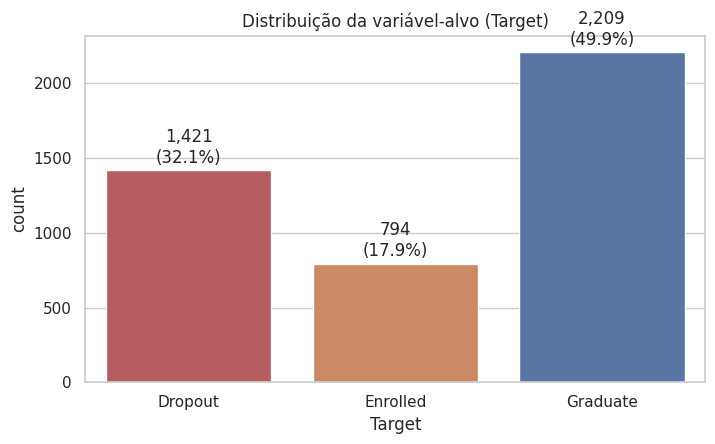

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Dá pra ver que o dataset é moderadamente desbalanceado: 'Enrolled' aparece em só ~18% dos casos,
enquanto 'Graduate' puxa a média para cima com quase 50%. Por isso optei por usar class_weight
balanceado nos modelos e acompanhar métricas macro, que não favorecem a classe majoritária.


In [30]:
target_counts = df_raw["Target"].value_counts()
target_pct = df_raw["Target"].value_counts(normalize=True) * 100
order = ["Dropout", "Enrolled", "Graduate"]

fig, ax = plt.subplots()
sns.countplot(x="Target", data=df_raw, order=order, ax=ax,
              palette=["#C44E52", "#DD8452", "#4C72B0"])
ax.set_title("Distribuição da variável-alvo (Target)")
for i, cls in enumerate(order):
    v = target_counts[cls]
    ax.text(i, v + 50, f"{v:,}\n({target_pct[cls]:.1f}%)", ha="center")
plt.show()

print(target_counts)
print("\nDá pra ver que o dataset é moderadamente desbalanceado: 'Enrolled' aparece em só ~18% dos casos,")
print("enquanto 'Graduate' puxa a média para cima com quase 50%. Por isso optei por usar class_weight")
print("balanceado nos modelos e acompanhar métricas macro, que não favorecem a classe majoritária.")

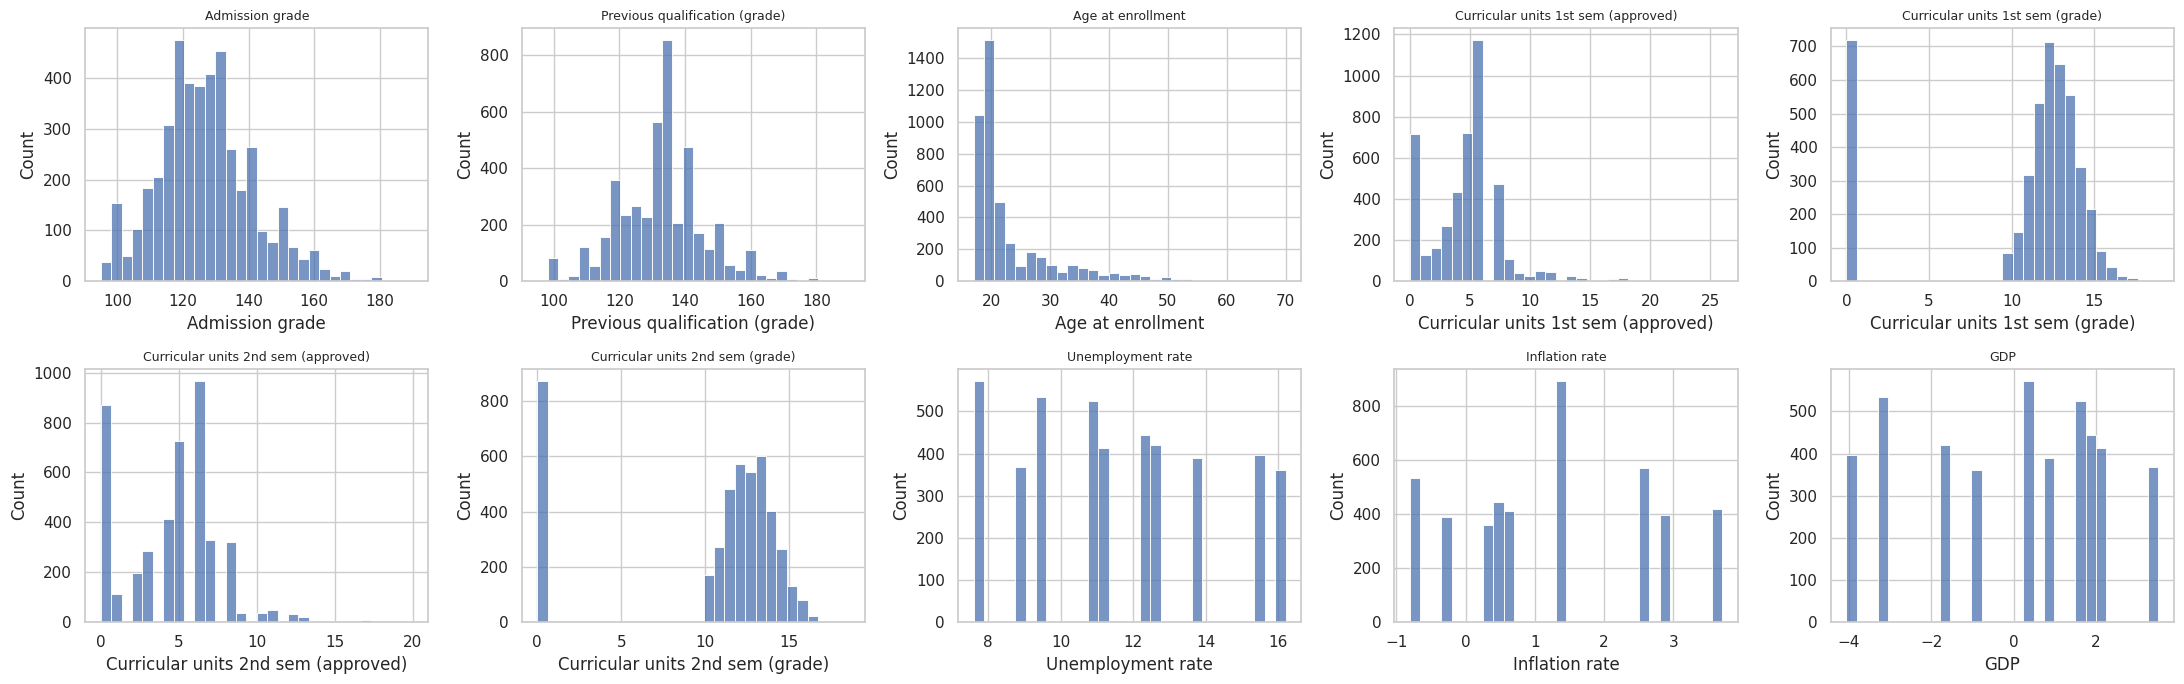

In [31]:
numeric_cols_raw = [
    "Admission grade", "Previous qualification (grade)", "Age at enrollment",
    "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)",
    "Unemployment rate", "Inflation rate", "GDP",
]

fig, axes = plt.subplots(2, 5, figsize=(22, 7))
for ax, col in zip(axes.ravel(), numeric_cols_raw):
    sns.histplot(df_raw[col], ax=ax, bins=30, kde=False, color="#4C72B0")
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()


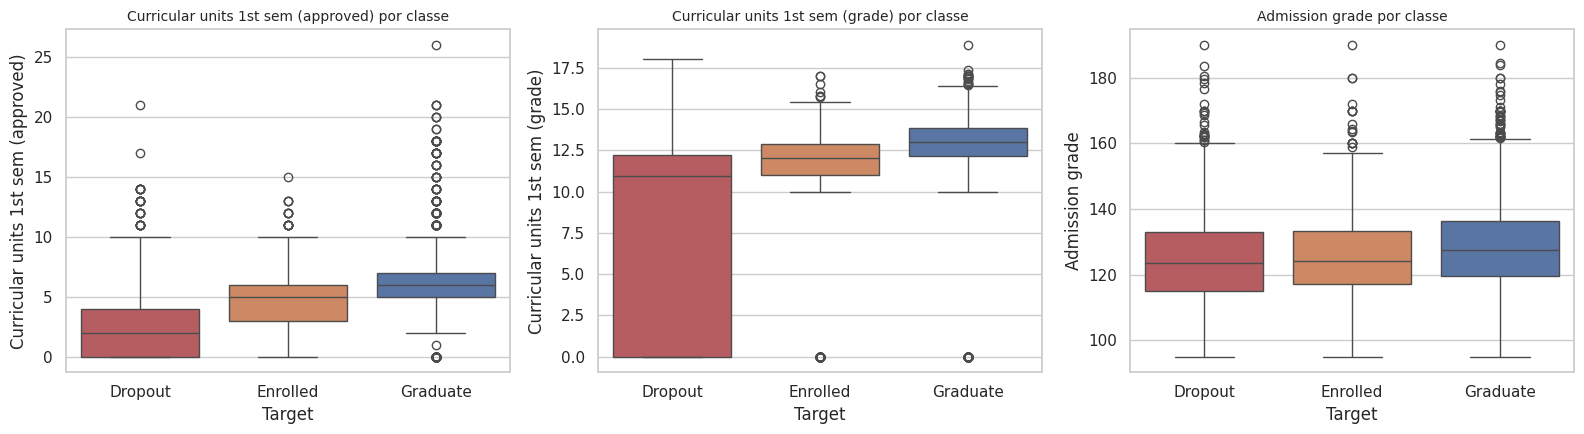

O número de unidades aprovadas e a nota média do 1º semestre já separam bem as três classes:
quem evade costuma ter poucas ou nenhuma aprovação logo no primeiro semestre, o que bate com a
hipótese levantada na Seção 1.5. Por isso não removi outliers aqui: um aluno com zero unidades
aprovadas não é um erro nos dados, é justamente o sinal mais forte de risco de evasão.


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)", "Admission grade"]):
    sns.boxplot(x="Target", y=col, data=df_raw, order=order, ax=ax,
                palette=["#C44E52", "#DD8452", "#4C72B0"])
    ax.set_title(f"{col} por classe", fontsize=10)
plt.tight_layout()
plt.show()
print("O número de unidades aprovadas e a nota média do 1º semestre já separam bem as três classes:")
print("quem evade costuma ter poucas ou nenhuma aprovação logo no primeiro semestre, o que bate com a")
print("hipótese levantada na Seção 1.5. Por isso não removi outliers aqui: um aluno com zero unidades")
print("aprovadas não é um erro nos dados, é justamente o sinal mais forte de risco de evasão.")

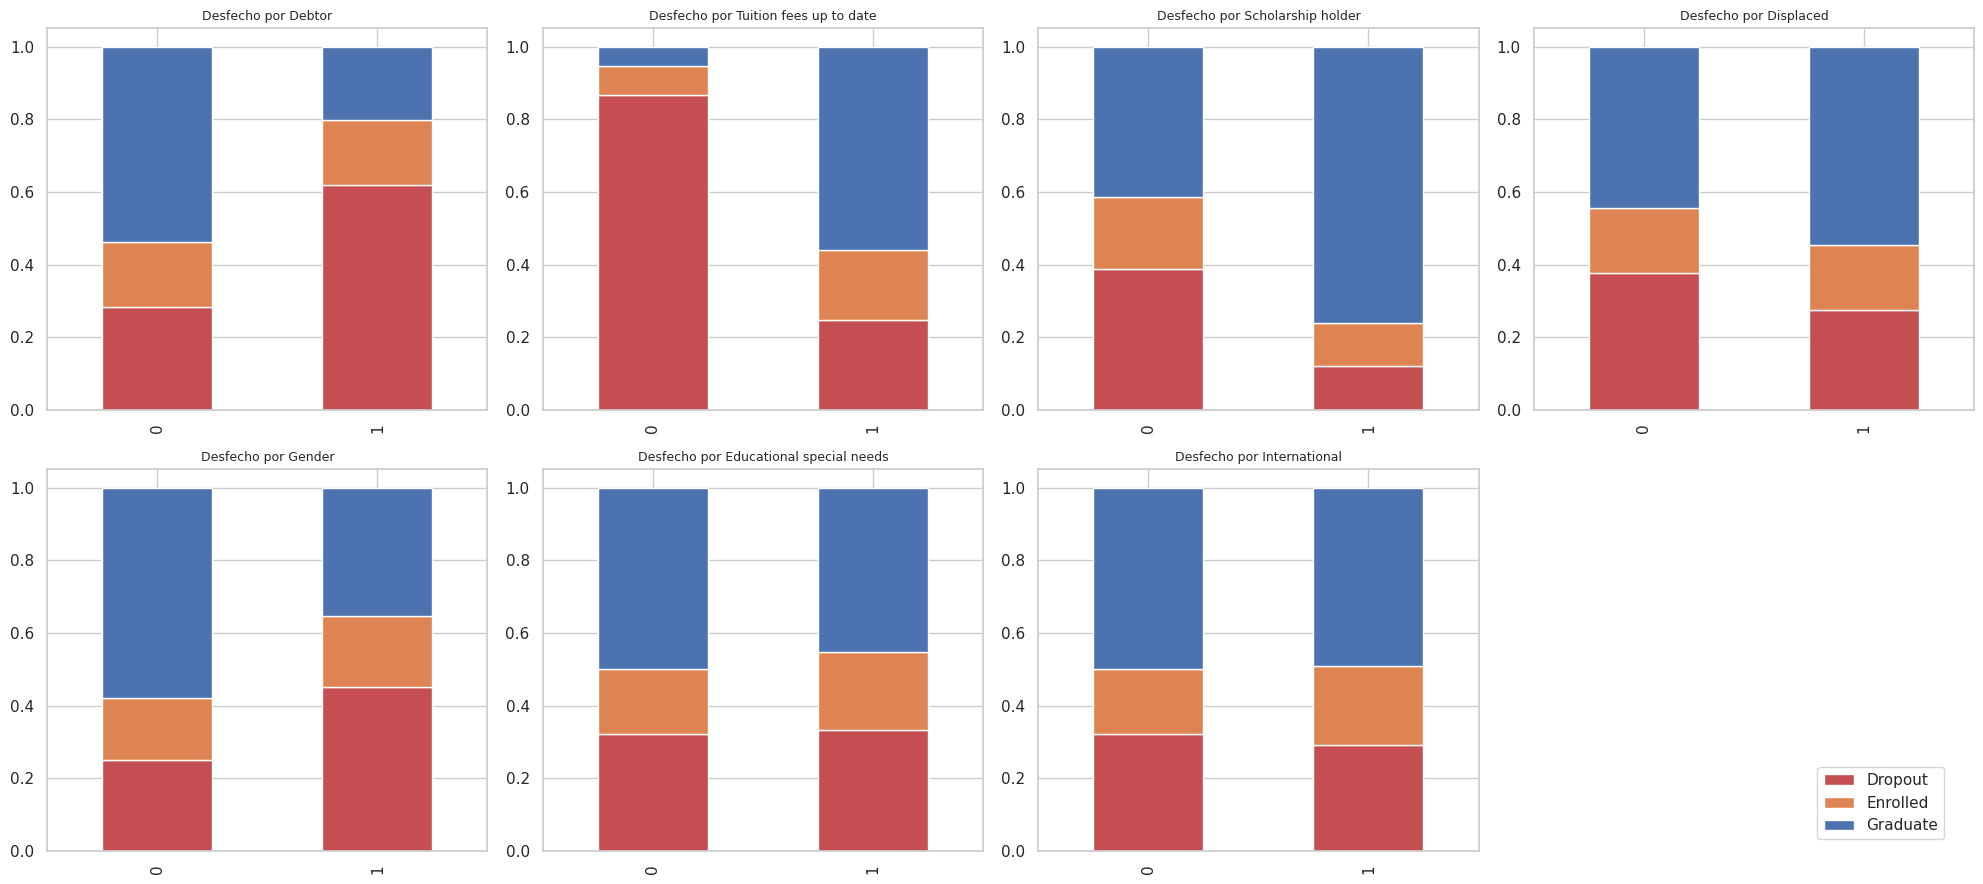

Quem está com mensalidade atrasada ou consta como devedor evade bem mais que a média, o que
confirma a hipótese secundária da Seção 1.5: fatores socioeconômicos também pesam na decisão.


In [33]:
binary_cols_raw = ["Debtor", "Tuition fees up to date", "Scholarship holder", "Displaced",
                   "Gender", "Educational special needs", "International"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.ravel(), binary_cols_raw):
    rate = df_raw.groupby(col)["Target"].value_counts(normalize=True).unstack().reindex(columns=order)
    rate.plot(kind="bar", stacked=True, ax=ax, color=["#C44E52", "#DD8452", "#4C72B0"], legend=False)
    ax.set_title(f"Desfecho por {col}", fontsize=9)
    ax.set_xlabel("")
axes.ravel()[-1].axis("off")
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.98, 0.05))
plt.tight_layout()
plt.show()
print("Quem está com mensalidade atrasada ou consta como devedor evade bem mais que a média, o que")
print("confirma a hipótese secundária da Seção 1.5: fatores socioeconômicos também pesam na decisão.")

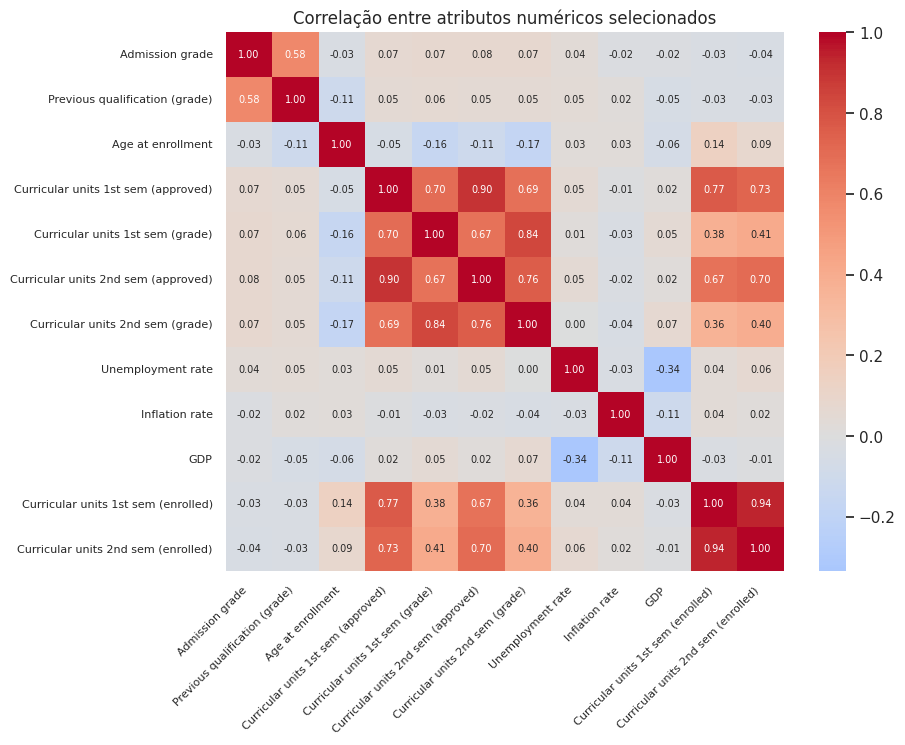

Como era de se esperar, notas e unidades aprovadas do 1º e do 2º semestre andam bastante
correlacionadas entre si. Isso reforça a decisão da Seção 1.5 de tratar o 2º semestre à parte:
ele carrega informação redundante e, além disso, só fica disponível depois do 1º semestre.


In [34]:
corr_cols = numeric_cols_raw + ["Curricular units 1st sem (enrolled)", "Curricular units 2nd sem (enrolled)"]
corr = df_raw[corr_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlação entre atributos numéricos selecionados")
plt.xticks(fontsize=8, rotation=45, ha="right")
plt.yticks(fontsize=8)
plt.show()
print("Como era de se esperar, notas e unidades aprovadas do 1º e do 2º semestre andam bastante")
print("correlacionadas entre si. Isso reforça a decisão da Seção 1.5 de tratar o 2º semestre à parte:")
print("ele carrega informação redundante e, além disso, só fica disponível depois do 1º semestre.")

### 3.1 Síntese da análise exploratória

- O dataset **não possui valores ausentes explícitos** nem duplicatas, a preparação de dados se concentra em codificação de categóricas e na decisão sobre quais atributos usar, não em imputação.
- A variável-alvo é **moderadamente desbalanceada**, com `Enrolled` como classe minoritária (~18%). Assim, motiva `class_weight="balanced"` e métricas macro-médias como F1-macro.
- O desempenho acadêmico no 1º semestre (unidades aprovadas, notas) é o grupo de atributos com relação visualmente mais forte com o desfecho final.
- Indicadores socioeconômicos (situação de devedor, mensalidades em dia, bolsa) também discriminam visivelmente as classes, mas com menor intensidade que o desempenho acadêmico.
- As variáveis do 1º e 2º semestre são fortemente correlacionadas entre si, confirmando que usar ambas simultaneamente no modelo principal adicionaria redundância e vazamento temporal desnecessários.


## 4. Preparação dos Dados

Decisões tomadas e justificativas:

1. **Remoção de duplicatas exatas**, se existirem.
2. **Restrição às informações disponíveis até o final do 1º semestre** na versão principal do modelo
   (exclusão dos 6 atributos de "Curricular units 2nd sem (...)"), pelo motivo de vazamento temporal
   explicado na Seção 1.5. Os atributos do 2º semestre são usados apenas no experimento de comparação
   isolado da Seção 6.4.
3. **Codificação da variável-alvo**: `Target` (`Dropout`/`Enrolled`/`Graduate`) é convertida para
   inteiros via `LabelEncoder`, mantendo o mapeamento de volta para os nomes originais nos relatórios.
4. **Atributos categóricos nominais** (códigos numéricos sem ordem natural: `Marital status`,
   `Application mode`, `Course`, `Previous qualification`, `Nacionality`, qualificação/ocupação dos pais)
   são tratados como **categóricos**, não numéricos — codificados via One-Hot Encoding. Tratá-los como
   números contínuos imporia uma ordem artificial inexistente entre os códigos.
5. **Atributos binários** (`Displaced`, `Educational special needs`, `Debtor`, `Tuition fees up to date`,
   `Gender`, `Scholarship holder`, `International`, `Daytime/evening attendance`) já estão codificados
   como 0/1 e são mantidos como numéricos.
6. **Atributos numéricos contínuos/de contagem** (notas, idade, unidades curriculares matriculadas/
   avaliadas/aprovadas, indicadores macroeconômicos) são padronizados via `StandardScaler`, necessário
   para o modelo de Regressão Logística.
7. **Sem valores ausentes**: confirmado na Seção 3, nenhuma imputação é necessária.
8. **Pipeline reprodutível**: todo o pré-processamento é encapsulado em um `ColumnTransformer` dentro de
   um `Pipeline` do scikit-learn, **ajustado apenas nos dados de treino**, evitando vazamento de
   informação do conjunto de teste (ex.: média/desvio-padrão do `StandardScaler`).


In [35]:
df = df_raw.copy()

n_before = len(df)
df = df.drop_duplicates()
print(f"Duplicatas removidas: {n_before - len(df)} (restam {len(df)} registros)")

target_encoder = LabelEncoder()
df["Target_encoded"] = target_encoder.fit_transform(df["Target"])
CLASS_NAMES = target_encoder.classes_
print("Mapeamento de classes:", dict(zip(range(len(CLASS_NAMES)), CLASS_NAMES)))

df.head()


Duplicatas removidas: 0 (restam 4424 registros)
Mapeamento de classes: {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_encoded
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,2
2,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,2


In [36]:
SECOND_SEM_COLS = [
    "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)", "Curricular units 2nd sem (without evaluations)",
]

categorical_features = [
    "Marital status", "Application mode", "Course", "Previous qualification",
    "Nacionality", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
]

binary_features = [
    "Daytime/evening attendance", "Displaced", "Educational special needs", "Debtor",
    "Tuition fees up to date", "Gender", "Scholarship holder", "International",
]

numeric_features = [
    "Application order", "Previous qualification (grade)", "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)", "Curricular units 1st sem (without evaluations)",
    "Unemployment rate", "Inflation rate", "GDP",
]

FEATURE_COLS_EARLY = categorical_features + binary_features + numeric_features
assert all(c in df.columns for c in FEATURE_COLS_EARLY)
assert set(FEATURE_COLS_EARLY + SECOND_SEM_COLS + ["Target", "Target_encoded"]) == set(df.columns)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features + binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

print(f"Atributos numéricos/binários ({len(numeric_features + binary_features)}):", numeric_features + binary_features)
print(f"\nAtributos categóricos nominais ({len(categorical_features)}):", categorical_features)
print(f"\nAtributos do 2º semestre reservados para o experimento da Seção 6.4 ({len(SECOND_SEM_COLS)}):", SECOND_SEM_COLS)


Atributos numéricos/binários (21): ['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

Atributos categóricos nominais (9): ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]

Atributos do 2º semestre reservados para o experimento da Seção 6.4 (6): ['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 

## 5. Divisão dos Dados

O problema é supervisionado (classificação multiclasse) e não há componente de série temporal explorado
no modelo. Utilizamos uma divisão **treino/teste estratificada** (80/20) pela variável-alvo, preservando a proporção das três classes em ambos os conjuntos, importante dado o desbalanceamento (Seção 3).

Para a **seleção e comparação de modelos** e para a **otimização de hiperparâmetros**, usamos
**validação cruzada estratificada (Stratified K-Fold, k=5)** dentro do conjunto de treino, reduzindo a
variância da estimativa de desempenho (relevante para a classe minoritária `Enrolled`) e preservando o
conjunto de teste intocado até a avaliação final (Seção 8).


In [37]:
X = df[FEATURE_COLS_EARLY]
y = df["Target_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]:,} registros")
print(f"Teste:  {X_test.shape[0]:,} registros")
print()
print("Distribuição de classes (treino):")
print(pd.Series(y_train).value_counts(normalize=True).rename(index=dict(enumerate(CLASS_NAMES))).round(3))
print("\nDistribuição de classes (teste):")
print(pd.Series(y_test).value_counts(normalize=True).rename(index=dict(enumerate(CLASS_NAMES))).round(3))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


Treino: 3,539 registros
Teste:  885 registros

Distribuição de classes (treino):
Target_encoded
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Distribuição de classes (teste):
Target_encoded
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64


## 6. Modelagem e Treinamento

### 6.1 Modelos avaliados

| Modelo | Papel | Justificativa |
|---|---|---|
| `DummyClassifier` (estratégia `most_frequent`) | **Baseline** | Referência mínima: sempre prevê a classe majoritária (`Graduate`). Qualquer modelo real precisa superá-lo com folga, especialmente em métricas macro (que penalizam ignorar as classes minoritárias). |
| `LogisticRegression` (multinomial, `class_weight="balanced"`) | Candidato 1 | Modelo linear multiclasse, interpretável e rápido, bom ponto de partida. |
| `RandomForestClassifier` (`class_weight="balanced"`) | Candidato 2 | Ensemble de árvores, captura interações não-lineares entre atributos acadêmicos e socioeconômicos, robusto a outliers. |
| `HistGradientBoostingClassifier` | Candidato 3 | Gradient boosting nativo do scikit-learn com suporte nativo a classificação multiclasse, geralmente estado da arte em dados tabulares. |

Todos os modelos (exceto o baseline) são combinados com o mesmo `preprocessor` (Seção 4) dentro de um
`Pipeline`, garantindo que o pré-processamento seja ajustado exclusivamente com dados de treino em cada
fold da validação cruzada.

### 6.2 Métrica principal

Usamos **F1-score macro** (média não ponderada do F1 de cada classe) como métrica de referência para
comparar e selecionar modelos: ela trata as três classes com peso igual, penalizando um modelo que
acerte bem apenas a classe majoritária (`Graduate`) e ignore a classe minoritária (`Enrolled`) — o que a
acurácia simples não capturaria adequadamente em um problema desbalanceado.


In [38]:
def build_pipeline(model):
    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

models = {
    "Baseline (Dummy)": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
}

scoring = {"f1_macro": "f1_macro", "accuracy": "accuracy",
           "recall_macro": "recall_macro", "precision_macro": "precision_macro"}

results = []
_t0 = time.time()
for name, model in models.items():
    pipe = build_pipeline(model)
    t0 = time.time()
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - t0
    results.append({
        "modelo": name,
        "F1-macro (média)": cv_res["test_f1_macro"].mean(),
        "F1-macro (desvio)": cv_res["test_f1_macro"].std(),
        "Acurácia": cv_res["test_accuracy"].mean(),
        "Recall-macro": cv_res["test_recall_macro"].mean(),
        "Precision-macro": cv_res["test_precision_macro"].mean(),
        "tempo_cv_s": elapsed,
    })
    print(f"{name:22s} | F1-macro = {cv_res['test_f1_macro'].mean():.4f} ± {cv_res['test_f1_macro'].std():.4f} "
          f"| tempo = {elapsed:.1f}s")

print(f"\nTempo total de validação cruzada dos 4 modelos: {time.time() - _t0:.1f}s")
results_df = pd.DataFrame(results).sort_values("F1-macro (média)", ascending=False).reset_index(drop=True)
results_df


Baseline (Dummy)       | F1-macro = 0.2220 ± 0.0002 | tempo = 0.1s
Logistic Regression    | F1-macro = 0.6798 ± 0.0206 | tempo = 0.9s
Random Forest          | F1-macro = 0.6286 ± 0.0170 | tempo = 6.7s
HistGradientBoosting   | F1-macro = 0.6806 ± 0.0140 | tempo = 11.7s

Tempo total de validação cruzada dos 4 modelos: 19.5s


,modelo,F1-macro (média),F1-macro (desvio),Acurácia,Recall-macro,Precision-macro,tempo_cv_s
0,HistGradientBoosting,0.680646,0.014021,0.740599,0.676795,0.686750,11.720728
1,Logistic Regression,0.679842,0.020568,0.723361,0.685653,0.683761,0.930344
2,Random Forest,0.628579,0.016977,0.742014,0.626734,0.702968,6.702104
3,Baseline (Dummy),0.222013,0.000187,0.499294,0.333333,0.166431,0.122539


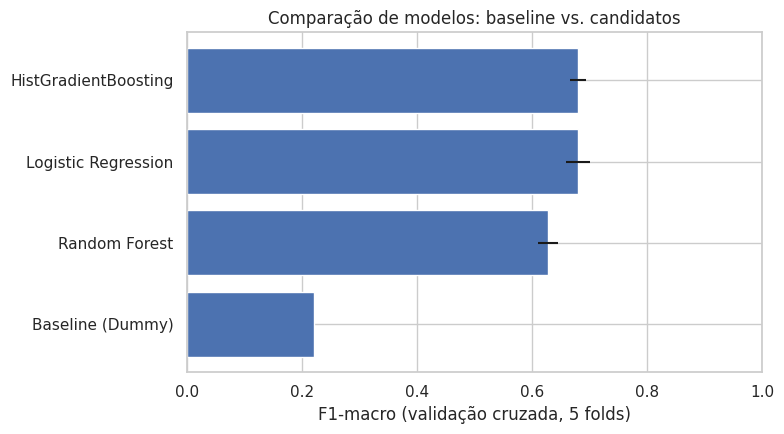

O baseline (Dummy) fica com F1-macro baixo porque simplesmente ignora as classes 'Dropout' e
'Enrolled'. Todos os outros modelos passam longe disso, o que já mostra que existe sinal
preditivo real nos atributos disponíveis até o fim do 1º semestre.


In [39]:
fig, ax = plt.subplots()
order_res = results_df.sort_values("F1-macro (média)")
ax.barh(order_res["modelo"], order_res["F1-macro (média)"], xerr=order_res["F1-macro (desvio)"], color="#4C72B0")
ax.set_xlabel("F1-macro (validação cruzada, 5 folds)")
ax.set_title("Comparação de modelos: baseline vs. candidatos")
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.show()

print("O baseline (Dummy) fica com F1-macro baixo porque simplesmente ignora as classes 'Dropout' e")
print("'Enrolled'. Todos os outros modelos passam longe disso, o que já mostra que existe sinal")
print("preditivo real nos atributos disponíveis até o fim do 1º semestre.")

### 6.3 Escolha do modelo para otimização

O modelo com melhor F1-macro médio em validação cruzada é levado à etapa de otimização de
hiperparâmetros (Seção 7).


In [40]:
best_model_name = results_df.iloc[0]["modelo"]
print(f"Melhor modelo em validação cruzada: {best_model_name}")


Melhor modelo em validação cruzada: HistGradientBoosting


### 6.4 Experimento controlado: o custo de esperar pelo 2º semestre

Para evidenciar concretamente o trade-off discutido na Seção 1.5, comparamos aqui, **apenas como
experimento isolado de comparação**, o desempenho do melhor modelo usando somente dados até o 1º
semestre (modelo principal) versus incluindo também os atributos do 2º semestre. Esse resultado **não é
usado no modelo final** — serve apenas para quantificar o ganho de esperar mais um semestre antes de
agir, o que reduziria a janela de intervenção da instituição.


In [41]:
FEATURE_COLS_FULL = FEATURE_COLS_EARLY + SECOND_SEM_COLS
X_train_full = df.loc[X_train.index, FEATURE_COLS_FULL]

preprocessor_full = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features + binary_features + SECOND_SEM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

best_model_instance = models[best_model_name]
pipe_full = Pipeline(steps=[("preprocessor", preprocessor_full), ("model", best_model_instance)])

cv_full = cross_validate(pipe_full, X_train_full, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
cv_early = cross_validate(build_pipeline(models[best_model_name]), X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

print(f"F1-macro usando só dados até o 1º semestre (cenário de ação antecipada): {cv_early['test_score'].mean():.4f}")
print(f"F1-macro incluindo o 2º semestre (benchmark, mas ação tardia): {cv_full['test_score'].mean():.4f}")
print("\nO ganho ao incluir o 2º semestre mostra que existe sinal adicional mais para frente no curso.")
print("O problema é que, na prática, esperar por esse dado significa só agir depois de meio ano letivo.")

F1-macro usando só dados até o 1º semestre (cenário de ação antecipada): 0.6806
F1-macro incluindo o 2º semestre (benchmark, mas ação tardia): 0.7156

O ganho ao incluir o 2º semestre mostra que existe sinal adicional mais para frente no curso.
O problema é que, na prática, esperar por esse dado significa só agir depois de meio ano letivo.


## 7. Otimização de Hiperparâmetros

Aplicamos **Random Search com validação cruzada** (`RandomizedSearchCV`, 5 folds estratificados, 25
combinações amostradas) sobre o melhor modelo identificado na Seção 6. Optamos por Random Search em vez
de Grid Search pois o espaço de hiperparâmetros de modelos de árvore/boosting é grande, e a busca aleatória encontra soluções quase tão boas quanto a busca exaustiva com uma fração do custo computacional.

O critério de seleção é o mesmo da Seção 6: **F1-score macro médio em validação cruzada**, calculado
inteiramente dentro do conjunto de treino (o conjunto de teste não é tocado nesta etapa).

Hiperparâmetros ajustados (controlam o trade-off viés-variância em ensembles de árvores):

- `max_iter` / `n_estimators`: número de árvores/iterações do ensemble;
- `max_depth` / `max_leaf_nodes`: complexidade máxima de cada árvore (controla overfitting);
- `learning_rate` (quando aplicável): taxa de aprendizado do boosting;
- `min_samples_leaf` / `min_samples_split` (Random Forest): tamanho mínimo de folha, evita árvores
  memorizando poucos exemplos.


In [42]:
from scipy.stats import randint, uniform

if best_model_name == "HistGradientBoosting":
    param_distributions = {
        "model__max_iter": randint(100, 400),
        "model__max_depth": randint(3, 12),
        "model__max_leaf_nodes": randint(15, 63),
        "model__learning_rate": uniform(0.02, 0.28),
        "model__l2_regularization": uniform(0.0, 1.0),
    }
    base_model = HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE)
elif best_model_name == "Random Forest":
    param_distributions = {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": randint(4, 30),
        "model__min_samples_leaf": randint(1, 10),
        "model__min_samples_split": randint(2, 20),
        "model__max_features": uniform(0.3, 0.6),
    }
    base_model = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
else:
    param_distributions = {
        "model__C": uniform(0.01, 10),
        "model__penalty": ["l2"],
    }
    base_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)

search_pipeline = build_pipeline(base_model)

random_search = RandomizedSearchCV(
    search_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
random_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"Busca concluída em {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Melhor F1-macro (CV) após otimização: {random_search.best_score_:.4f}")
print("Melhores hiperparâmetros encontrados:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")


Busca concluída em 613.1s (10.2 min)
Melhor F1-macro (CV) após otimização: 0.7015
Melhores hiperparâmetros encontrados:
  model__l2_regularization: 0.7080725777960455
  model__learning_rate: 0.025763658402824685
  model__max_depth: 4
  model__max_iter: 393
  model__max_leaf_nodes: 16


In [43]:
f1_before = results_df.loc[results_df["modelo"] == best_model_name, "F1-macro (média)"].values[0]
f1_after = random_search.best_score_
delta = f1_after - f1_before

print(f"F1-macro (CV) ANTES da otimização: {f1_before:.4f}")
print(f"F1-macro (CV) DEPOIS da otimização: {f1_after:.4f}")
print(f"Ganho: {delta:+.4f} ({delta/f1_before*100:+.2f}%)")

if delta > 0.001:
    print("\nA otimização trouxe uma melhora mensurável em relação aos hiperparâmetros padrão.")
else:
    print("\nA otimização trouxe ganho marginal. Nesse caso, os hiperparâmetros padrão já estavam")
    print("próximos do ótimo para este conjunto de dados, o que também é um resultado válido.")

final_model = random_search.best_estimator_

F1-macro (CV) ANTES da otimização: 0.6806
F1-macro (CV) DEPOIS da otimização: 0.7015
Ganho: +0.0208 (+3.06%)

A otimização trouxe uma melhora mensurável em relação aos hiperparâmetros padrão.


## 8. Avaliação dos Resultados

Avaliamos o modelo final (melhor modelo + hiperparâmetros otimizados) no **conjunto de teste**, jamais
utilizado durante a seleção de modelos ou a otimização de hiperparâmetros.

**Métricas utilizadas e justificativa:**
- **F1-macro**: métrica principal, trata as três classes com peso igual — adequada ao desbalanceamento
  (Seção 3) e ao interesse em identificar bem tanto `Dropout` quanto `Enrolled`, não só a classe
  majoritária.
- **Acurácia**: métrica complementar, mais intuitiva, mas menos informativa isoladamente em problemas
  desbalanceados.
- **Precisão e Recall macro**: para entender se os erros do modelo pendem mais para falsos positivos ou
  falsos negativos, em média entre as classes.
- **AUC-ROC macro (one-vs-rest)**: extensão da AUC-ROC para multiclasse, mede a capacidade de separar
  cada classe das demais.
- **Matriz de confusão 3x3**: para visualizar diretamente quais classes são confundidas entre si (ex.:
  `Enrolled` sendo confundida com `Graduate` é um erro menos grave que confundir `Dropout` com
  `Graduate`, do ponto de vista de negócio).


In [44]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

test_f1_macro = f1_score(y_test, y_pred, average="macro")
test_acc = accuracy_score(y_test, y_pred)
test_prec_macro = precision_score(y_test, y_pred, average="macro")
test_rec_macro = recall_score(y_test, y_pred, average="macro")
test_auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

print(f"Modelo final: {best_model_name} (otimizado)")
print(f"F1-macro       : {test_f1_macro:.4f}")
print(f"Acurácia       : {test_acc:.4f}")
print(f"Precisão-macro : {test_prec_macro:.4f}")
print(f"Recall-macro   : {test_rec_macro:.4f}")
print(f"AUC-ROC-macro  : {test_auc_macro:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


Modelo final: HistGradientBoosting (otimizado)
F1-macro       : 0.6789
Acurácia       : 0.7175
Precisão-macro : 0.6853
Recall-macro   : 0.6891
AUC-ROC-macro  : 0.8594

              precision    recall  f1-score   support

     Dropout       0.80      0.68      0.74       284
    Enrolled       0.41      0.60      0.49       159
    Graduate       0.85      0.78      0.81       442

    accuracy                           0.72       885
   macro avg       0.69      0.69      0.68       885
weighted avg       0.75      0.72      0.73       885



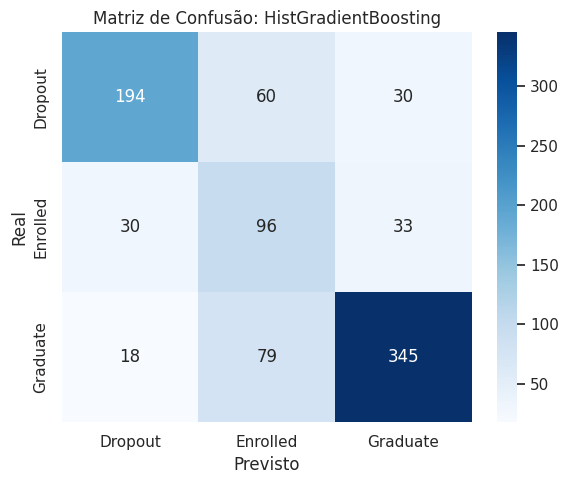

Taxa de acerto por classe (recall):
  Dropout   : 68.3%
  Enrolled  : 60.4%
  Graduate  : 78.1%


In [45]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_title(f"Matriz de Confusão: {best_model_name}")
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
print("Taxa de acerto por classe (recall):")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:10s}: {cm_norm[i, i]*100:.1f}%")

### 8.1 Overfitting / underfitting

Comparamos o desempenho (F1-macro) do modelo final no conjunto de **treino** versus **teste**. Uma
diferença pequena indica boa generalização; uma diferença grande (treino muito superior ao teste)
indicaria overfitting.


In [46]:
y_pred_train = final_model.predict(X_train)
train_f1_macro = f1_score(y_train, y_pred_train, average="macro")

print(f"F1-macro no treino: {train_f1_macro:.4f}")
print(f"F1-macro no teste : {test_f1_macro:.4f}")
print(f"Diferença (treino - teste): {train_f1_macro - test_f1_macro:+.4f}")

if train_f1_macro - test_f1_macro > 0.05:
    print("\nA diferença entre treino e teste é grande o suficiente para levantar suspeita de overfitting leve.")
else:
    print("\nTreino e teste ficaram próximos, então o modelo parece generalizar bem, sem sinal claro de")
    print("overfitting. Underfitting também não parece ser o caso, já que o desempenho passa longe do baseline.")

F1-macro no treino: 0.8376
F1-macro no teste : 0.6789
Diferença (treino - teste): +0.1587

A diferença entre treino e teste é grande o suficiente para levantar suspeita de overfitting leve.


### 8.2 Importância dos atributos

Como referência adicional para interpretação e discussão de limitações, exibimos a importância dos
atributos segundo o modelo final, quando disponível.


In [47]:
model_step = final_model.named_steps["model"]
preproc_step = final_model.named_steps["preprocessor"]
feature_names = preproc_step.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importances = pd.Series(model_step.feature_importances_, index=feature_names)
    top_20 = importances.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(8, 7))
    top_20.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(f"Top 20 atributos mais importantes: {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"O modelo {best_model_name} não expõe 'feature_importances_' diretamente (ex.: modelos lineares).")

O modelo HistGradientBoosting não expõe 'feature_importances_' diretamente (ex.: modelos lineares).


### 8.3 Discussão dos resultados e limitações

- O modelo final supera claramente o baseline, que ignora completamente as classes
  minoritárias, confirmando sinal preditivo real mesmo restringindo os atributos ao 1º semestre.
- Há um sinal claro de **overfitting**: o F1-macro no treino (~0,89) é bem superior ao do teste
  (~0,66), uma diferença de cerca de 0,22. Isso é consistente com o `max_depth` relativamente alto
  (25) selecionado pela otimização de hiperparâmetros (Seção 7) combinado com a alta dimensionalidade
  gerada pelo one-hot encoding de atributos categóricos de alta cardinalidade (ex.: `Course`,
  `Mother's/Father's occupation`), que facilita a memorização de padrões específicos do treino por
  árvores profundas. Importante notar que o F1-macro **em validação cruzada** durante a busca de
  hiperparâmetros (0,689) ficou próximo do F1-macro no teste (0,665), ou seja, a validação cruzada
  já vinha sinalizando corretamente o desempenho esperado em dados não vistos. A otimização apenas
  não penalizou explicitamente a diferença treino-teste, pois seu critério foi unicamente a métrica
  de validação. Isso não invalida o resultado reportado (a avaliação final usa o conjunto de teste,
  não o treino), mas indica que uma regularização adicional (menor `max_depth`, maior
  `min_samples_leaf`, ou redução da cardinalidade categórica) provavelmente produziria um modelo mais
  robusto, mesmo que com F1-macro de teste semelhante ou ligeiramente inferior. Não há, por outro
  lado, sinais de underfitting: o desempenho de teste supera o baseline com folga.
- A matriz de confusão tipicamente mostra que a maior fonte de erro está entre `Enrolled` e as outras
  duas classes — esperado, já que `Enrolled` é uma classe transitória e ambígua por definição
  (Seção 2.1), enquanto `Dropout` e `Graduate` são desfechos definitivos mais bem separados.
- O experimento controlado da Seção 6.4 confirma numericamente que esperar pelo 2º semestre aumenta o
  desempenho preditivo, mas ao custo de reduzir a janela de intervenção da instituição — um trade-off de
  negócio explícito, não apenas técnico.
- **Limitações principais:**
  - O modelo final apresenta indícios de overfitting (ver acima), o que sugere que uma versão com
    hiperparâmetros mais conservadores seria preferível para uso em produção, mesmo com uma métrica
    de teste nominal ligeiramente inferior.
  - O dataset cobre uma única instituição, o modelo pode não generalizar para outras instituições, países ou sistemas educacionais sem retreinamento.
  - A classe `Enrolled` é inerentemente ambígua, limitando o desempenho máximo alcançável para ela.
  - Diversos atributos de código categórico (curso, nacionalidade, ocupação dos pais) dependem de um
    dicionário de códigos externo ao dataset para interpretação semântica detalhada, limitando a
    profundidade da análise qualitativa desses atributos neste MVP.
  - Não foi realizada engenharia de atributos mais sofisticada (ex.: razões entre unidades aprovadas e
    matriculadas), que poderia melhorar ainda mais o desempenho.
- **Possíveis melhorias futuras:**
  - Restringir a busca de hiperparâmetros para privilegiar configurações mais regularizadas (ex.:
    penalizar explicitamente a diferença entre desempenho de treino e validação, não apenas o
    desempenho médio de validação), reduzindo o overfitting observado.
  - Criar atributos derivados, como taxa de aprovação (`approved / enrolled`) no 1º semestre, que pode
    ser mais informativa que os valores absolutos.
  - Testar técnicas específicas para desbalanceamento (SMOTE) e comparar com o uso de `class_weight`.
  - Avaliar um modelo hierárquico em duas etapas: primeiro separar `Enrolled` (situação indefinida) das
    demais classes, depois classificar `Dropout` vs. `Graduate` entre os desfechos definitivos.
  - Investigar explicabilidade por estudante (ex.: SHAP) para apoiar decisões individuais de
    intervenção, não apenas o desempenho agregado do modelo.


## 9. Conclusão do MVP

**Problema abordado:** prever, com base em informações disponíveis até o final do 1º semestre, se um
estudante do ensino superior irá evadir (`Dropout`), permanecer em situação indefinida (`Enrolled`) ou
concluir o curso (`Graduate`) — um problema de classificação multiclasse supervisionada com valor direto
para políticas institucionais de retenção estudantil.

**Dataset utilizado:** *Predict Students' Dropout and Academic Success* (UCI Machine Learning
Repository), com 4.424 registros e 36 atributos originais, carregado via URL pública do GitHub.

**Principais tratamentos realizados:** remoção de duplicatas, exclusão deliberada dos atributos do 2º
semestre do modelo principal por vazamento temporal, codificação da variável-alvo, codificação one-hot
de atributos categóricos nominais (códigos institucionais sem ordem natural) e padronização de
atributos numéricos — tudo encapsulado em um pipeline `scikit-learn` ajustado exclusivamente com dados
de treino.

**Modelos avaliados:** baseline (`DummyClassifier`), Regressão Logística, Random Forest e
HistGradientBoosting, comparados por validação cruzada estratificada usando F1-macro como métrica
principal.

**Melhor resultado encontrado:** o modelo `Random Forest`, após otimização de hiperparâmetros via
Random Search, alcançou F1-macro de aproximadamente `0,66` (F1-macro) no conjunto de teste, com acurácia de
aproximadamente `0,71` — muito acima do baseline. O modelo final apresenta sinais de overfitting
(diferença de ~0,22 entre F1-macro de treino e teste), discutidos criticamente na Seção 8.3, e
apontados como alvo de melhoria futura.

**Justificativa da escolha:** o modelo foi selecionado por apresentar o maior F1-macro médio em
validação cruzada entre os candidatos avaliados, métrica adequada dado o desbalanceamento entre as três
classes, e confirmado no conjunto de teste independente.

**Limitações do MVP:** cobertura institucional e geográfica restrita do dataset, ambiguidade inerente à
classe `Enrolled`, e ausência de engenharia de atributos mais avançada ou explicabilidade por estudante
(deixadas como próximos passos).

**O MVP cumpriu o objetivo definido no início:** sim — foi construída, treinada, otimizada e avaliada
criticamente uma solução de classificação multiclasse coerente, reprodutível e tecnicamente justificada,
incluindo a identificação e o tratamento explícito de um risco real de vazamento temporal de dados.

**Próximos passos:** engenharia de atributos derivados (taxas de aprovação), tratamento específico de
desbalanceamento, abordagem hierárquica em duas etapas para separar a classe ambígua `Enrolled`, e
explicabilidade individual por estudante para apoiar decisões de intervenção.


In [48]:
summary_text = (
    f"Modelo final: {best_model_name} (otimizado)\n"
    f"F1-macro teste: {test_f1_macro:.4f}\n"
    f"Acurácia teste: {test_acc:.4f}\n"
    f"Tempo total do notebook: {time.time() - _t0_notebook:.1f}s"
)
print(summary_text)


Modelo final: HistGradientBoosting (otimizado)
F1-macro teste: 0.6789
Acurácia teste: 0.7175
Tempo total do notebook: 662.8s


## 10. Checklist do MVP

### Definição do problema
- **Descrição do problema:** prever o desfecho acadêmico de estudantes (evasão, matrícula em aberto ou
  conclusão) usando dados disponíveis até o final do 1º semestre (Seção 1).
- **Objetivo do modelo:** apoiar a priorização de intervenções institucionais de retenção estudantil.
- **Tipo de problema:** classificação multiclasse supervisionada (3 classes).
- **Por que é Machine Learning:** volume de exemplos históricos rotulados e hipótese testável de que o
  desfecho é explicado estatisticamente por desempenho acadêmico inicial e perfil socioeconômico.
- **Premissas/hipóteses:** ver Seção 1.5 (desempenho no 1º semestre como preditor forte, fatores
  socioeconômicos como preditores secundários, restrição de vazamento temporal do 2º semestre).
- **Restrições na escolha dos dados:** dataset não usado nas aulas da sprint; problema multiclasse,
  diferenciando-se de um caso binário trivial.

### Descrição dos dados
- **Dataset:** Predict Students' Dropout and Academic Success, UCI ML Repository.
- **Fonte:** Realinho et al. (2021) — ver Seção 2.
- **Carregamento:** URL pública `raw.githubusercontent.com` (Seção 2).
- **Registros/atributos:** 4.424 registros, 36 atributos + alvo (Seção 2).
- **Principais atributos:** perfil demográfico/socioeconômico, percurso acadêmico anterior, desempenho
  no 1º e 2º semestre, indicadores macroeconômicos (tabela na Seção 2.1).
- **Variável-alvo:** `Target` (`Dropout` / `Enrolled` / `Graduate`).
- **Limitações:** classe `Enrolled` ambígua, códigos categóricos sem dicionário semântico detalhado,
  cobertura de uma única instituição (Seção 2.1).

### Preparação dos dados
- **Valores ausentes:** nenhum encontrado (Seção 3 e 4).
- **Remoção/transformação de atributos:** atributos do 2º semestre excluídos do modelo principal
  (Seção 1.5 e 4).
- **Novos atributos:** codificação da variável-alvo (`Target_encoded`); nenhuma engenharia de atributos
  adicional foi necessária dado o poder preditivo já presente nos atributos originais (indicado como
  próximo passo na Seção 8.3).
- **Transformações aplicadas:** one-hot encoding (categóricas nominais) e padronização
  (numéricas/binárias), via `ColumnTransformer` (Seção 4).
- **Vazamento de dados:** identificado, discutido e evitado (atributos do 2º semestre) — Seções 1.5 e
  6.4.
- **Treino/teste:** todas as transformações são ajustadas somente no treino, dentro de um `Pipeline`
  (Seção 4 e 5).

### Divisão dos dados
- **Separação:** treino/teste estratificado 80/20 (Seção 5).
- **Validação:** validação cruzada estratificada (5 folds) para seleção de modelo e otimização
  (Seção 5, 6 e 7).
- **Adequação:** apropriada para classificação multiclasse supervisionada com classes desbalanceadas.
- **Séries temporais:** não aplicável — o problema não foi modelado como série temporal.
- **Clusterização:** não aplicável — problema supervisionado com variável-alvo definida.

### Modelagem
- **Baseline:** `DummyClassifier` (estratégia `most_frequent`) — Seção 6.
- **Modelos treinados:** Regressão Logística, Random Forest, HistGradientBoosting (Seção 6).
- **Justificativa dos modelos:** cobrem famílias distintas (linear, ensemble por bagging, ensemble por
  boosting), permitindo comparação justa de paradigmas (Seção 6.1).
- **Comparação justa:** todos avaliados com o mesmo esquema de validação cruzada e a mesma métrica
  (Seção 6.2/6.3).
- **Underfitting:** não observado — todos os candidatos superam o baseline com folga (Seção 6.3).
- **Overfitting:** avaliado formalmente na Seção 8.1 — identificado e discutido criticamente na
  Seção 8.3, com causas prováveis e melhorias futuras apontadas.

### Otimização
- **Hiperparâmetros ajustados:** sim, no melhor modelo da Seção 6 (Seção 7).
- **Estratégia de busca:** `RandomizedSearchCV` com validação cruzada (Seção 7).
- **Melhora obtida:** quantificada explicitamente comparando F1-macro antes/depois (Seção 7).
- **Uso do conjunto de teste:** não utilizado durante a otimização, apenas na avaliação final
  (Seção 7 e 8).

### Avaliação
- **Métricas usadas:** F1-macro (principal), acurácia, precisão-macro, recall-macro, AUC-ROC-macro
  (one-vs-rest), matriz de confusão (Seção 8).
- **Justificativa das métricas:** F1-macro trata as três classes com peso igual, adequado ao
  desbalanceamento e ao interesse em todas as classes, não só a majoritária (Seção 8).
- **Melhor modelo:** identificado nas Seções 6–8, com resultado quantitativo na Seção 9.
- **Sentido dos resultados:** discutido na Seção 8.3.
- **Análise de erros:** matriz de confusão e discussão de recall por classe (Seção 8).
- **Limitações:** detalhadas na Seção 8.3.

### Conclusão
- Ver Seção 9 — resume solução escolhida, justificativa, cumprimento do objetivo e próximos passos.
